## Import Libraries

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Load the dataset

In [26]:
df=pd.read_csv("/home/home/code/Susanta2025-lab/Fatocheck/data/raw/WELFake_Dataset.csv", index_col=0)

## Data Verification

In [27]:
df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72134 entries, 0 to 72133
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   71576 non-null  object
 1   text    72095 non-null  object
 2   label   72134 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.2+ MB


In [29]:
df.label.value_counts()

label
1    37106
0    35028
Name: count, dtype: int64

In [30]:
df["label"].value_counts()

label
1    37106
0    35028
Name: count, dtype: int64

In [31]:
df.head(1)

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1


In [32]:
df.shape

(72134, 3)

In [33]:
df.isnull().sum()

title    558
text      39
label      0
dtype: int64

In [34]:
df.iloc[0]

title    LAW ENFORCEMENT ON HIGH ALERT Following Threat...
text     No comment is expected from Barack Obama Membe...
label                                                    1
Name: 0, dtype: object

## Combining Title and Text Columns
### Data Cleaning

In [35]:
df["content"] = (df["title"].fillna("") + " " + df["text"].fillna("")).str.strip()

In [36]:
df = df[['content', 'label']]

In [37]:
df.iloc[0]

content    LAW ENFORCEMENT ON HIGH ALERT Following Threat...
label                                                      1
Name: 0, dtype: object

In [38]:
df.isnull().sum()

content    0
label      0
dtype: int64

## Verification of labels assigned to Fake and Real News

In [39]:
print(df[df["label"]==1].head(1))

                                             content  label
0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...      1


In [40]:
print(df[df["label"]==0].head(1))

                                             content  label
3  Bobby Jindal, raised Hindu, uses story of Chri...      0


## Reversing the Labels of the dataset

In [41]:
# As we can see the label 1 is for fake news and label 0 is for real news in the original dataset. We are reversing the labels to make it more intuitive. So, we will replace 1 with 0 and 0 with 1.
# df['label'] = df['label'].replace({1: 0, 0: 1}) or
df['label'] = 1-df['label']

In [42]:
df["label"].value_counts()

label
0    37106
1    35028
Name: count, dtype: int64

## Distribution of Fake vs Real News

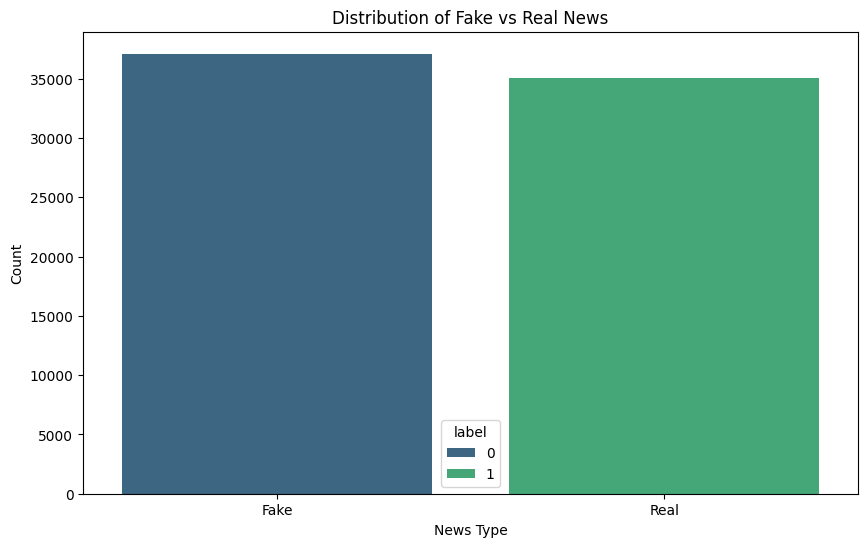

In [43]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x='label',
    hue='label',
    palette= 'viridis'
    )

plt.title('Distribution of Fake vs Real News')
plt.xlabel('News Type')
plt.ylabel('Count')
plt.xticks([0,1], ['Fake', 'Real'])
plt.show()